In [34]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/processed/aadhaar_demographic_all_records.csv")
df.head()
df.shape
df = df.drop(columns=['source_file'])
df.info()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   date           1048575 non-null  object
 1   state          1048575 non-null  object
 2   district       1048575 non-null  object
 3   pincode        1048575 non-null  int64 
 4   demo_age_5_17  1048575 non-null  int64 
 5   demo_age_17_   1048575 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 48.0+ MB


Index(['date', 'state', 'district', 'pincode', 'demo_age_5_17',
       'demo_age_17_'],
      dtype='object')

#2 data quality and validation

In [35]:
df.isnull().sum()


date             0
state            0
district         0
pincode          0
demo_age_5_17    0
demo_age_17_     0
dtype: int64

no missing values; complete dataset

In [36]:
(df == "").sum()

date             0
state            0
district         0
pincode          0
demo_age_5_17    0
demo_age_17_     0
dtype: int64

In [37]:
df.dtypes

date             object
state            object
district         object
pincode           int64
demo_age_5_17     int64
demo_age_17_      int64
dtype: object

In [38]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.dtypes
df.isnull().sum()

date             592997
state                 0
district              0
pincode               0
demo_age_5_17         0
demo_age_17_          0
dtype: int64

In [39]:
df.columns = df.columns.str.strip().str.lower()
df.columns.duplicated()
df = df.loc[:, ~df.columns.duplicated()]
df.dtypes
df = df.rename(columns={
    'demo_age_5_17': 'age_5_17',
    'demo_age_17_': 'age_17_plus'
})
df.dtypes

date           datetime64[ns]
state                  object
district               object
pincode                 int64
age_5_17                int64
age_17_plus             int64
dtype: object

In [ ]:
#child-adult ratio
df['child_to_' \
'adult_ratio'] = df['age_5_17'] / df['age_17_plus']
#time-based features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month


In [41]:
#state level aggregation
df['state'] = (
    df['state']
    .str.strip()
    .str.lower()
)
# Remove numeric garbage like '100000'
df = df[~df['state'].str.isnumeric()]

# Remove known non-state locations
df = df[~df['state'].isin(['balanagar', 'jaipur', 'madanapalle'])]

# Remove statistical noise
df = df[df['total_population'] > 100]

state_mapping = {
    # Andaman
    'andaman & nicobar islands': 'andaman and nicobar islands',
    'andaman and nicobar islands': 'andaman and nicobar islands',

    # Andhra
    'andhra pradesh': 'andhra pradesh',

    # West Bengal
    'west bengal': 'west bengal',
    'west bangal': 'west bengal',
    'westbengal': 'west bengal',
    'west bengli': 'west bengal',

    # Odisha
    'orissa': 'odisha',
    'odisha': 'odisha',

    # Uttarakhand
    'uttaranchal': 'uttarakhand',
    'uttarakhand': 'uttarakhand',

    # Puducherry
    'pondicherry': 'puducherry',
    'puducherry': 'puducherry',

    # Jammu & Kashmir
    'jammu & kashmir': 'jammu and kashmir',
    'jammu and kashmir': 'jammu and kashmir',

    # Dadra & Nagar Haveli / Daman & Diu
    'dadra & nagar haveli': 'dadra and nagar haveli and daman and diu',
    'dadra and nagar haveli': 'dadra and nagar haveli and daman and diu',
    'daman & diu': 'dadra and nagar haveli and daman and diu',
    'daman and diu': 'dadra and nagar haveli and daman and diu'
}
df['state'] = df['state'].replace(state_mapping)
state_summary = df.groupby('state')[['age_5_17', 'age_17_plus', 'total_population']].sum().reset_index()
state_summary

,state,age_5_17,age_17_plus,total_population
0,andaman and nicobar islands,71,741,812
1,andhra pradesh,64108,458217,522325
2,arunachal pradesh,385,3509,3894
3,assam,14070,148815,162885
4,bihar,94041,1197231,1291272
5,chandigarh,6306,26375,32681
6,chhattisgarh,53186,649323,702509
7,dadra and nagar haveli and daman and diu,162,1548,1710
8,delhi,87464,592935,680399
9,goa,366,2091,2457


data analysis

In [42]:
state_summary.shape
state_summary.head()
state_summary[['age_5_17', 'age_17_plus', 'total_population']].describe()

,age_5_17,age_17_plus,total_population
count,35.000000,3.500000e+01,3.500000e+01
mean,35858.628571,3.455915e+05,3.814501e+05
std,45539.839398,4.830624e+05,5.247358e+05
min,71.000000,7.410000e+02,8.120000e+02
25%,1538.000000,1.372150e+04,1.596400e+04
50%,16895.000000,1.488150e+05,1.628850e+05
75%,61839.000000,4.551020e+05,5.196300e+05
max,200565.000000,2.272333e+06,2.472898e+06


1.There is a significant disparity in the demographic size across all the states.
2. The mean is considerably higher than median, making it right skewed; meaning there are few highly populated states.
3. The standard deviation is quite high, meaning the variability is high, meaning we would need state specific Aadhaar enrollment strategies.

visualization

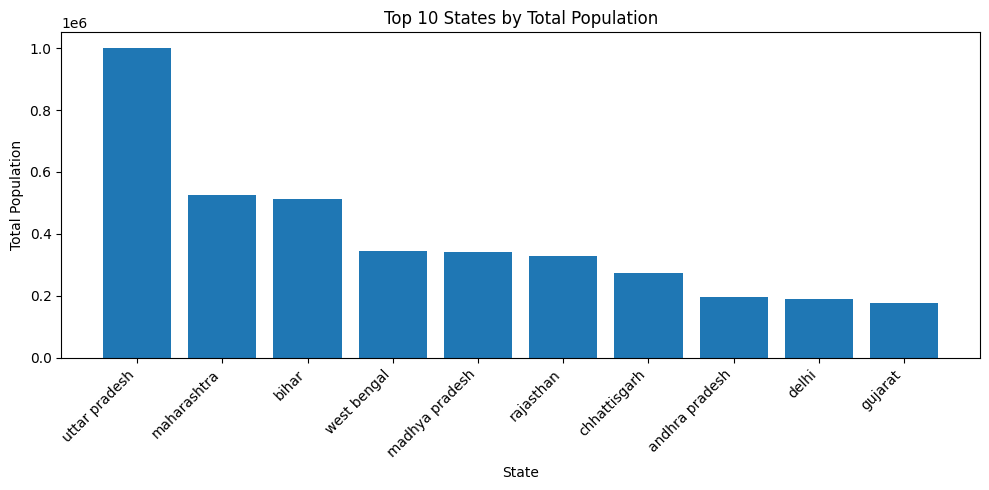

In [17]:
import matplotlib.pyplot as plt
top10 = state_summary.sort_values('total_population', ascending=False).head(10)
plt.figure(figsize=(10,5))
plt.bar(top10['state'], top10['total_population'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 States by Total Population')
plt.xlabel('State')
plt.ylabel('Total Population')
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_states_population.png", dpi=300)
plt.show()

These are the states that have highest share of demographic population. The high population in these states makes it important for them to have more infrastructure, centers and manpower

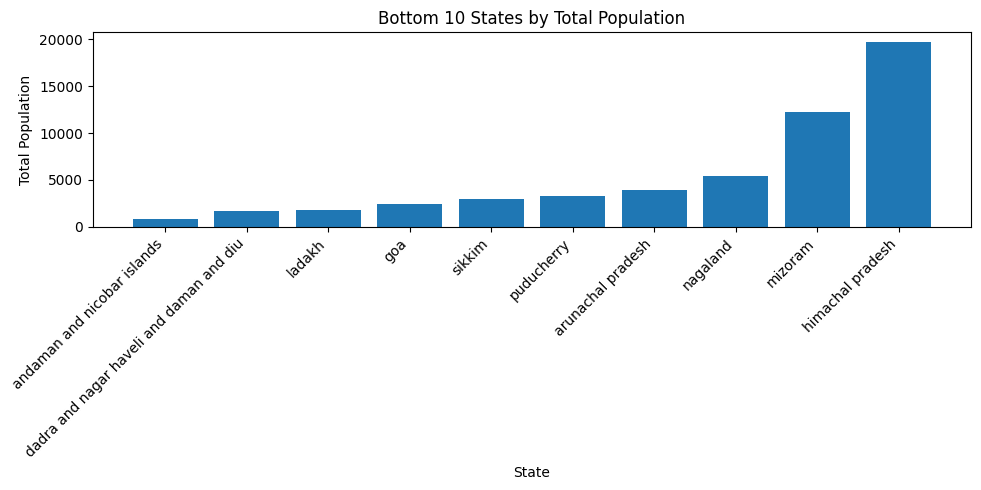

In [44]:
bottom10 = state_summary.sort_values('total_population').head(10)

plt.figure(figsize=(10,5))
plt.bar(bottom10['state'], bottom10['total_population'])
plt.xticks(rotation=45, ha='right')
plt.title('Bottom 10 States by Total Population')
plt.xlabel('State')
plt.ylabel('Total Population')
plt.tight_layout()
plt.savefig("../outputs/charts/_10bottom_states_population.png", dpi=300)
plt.show()


These states need a different enrollment strategy. They don't need scale. They need accessibility and reach.

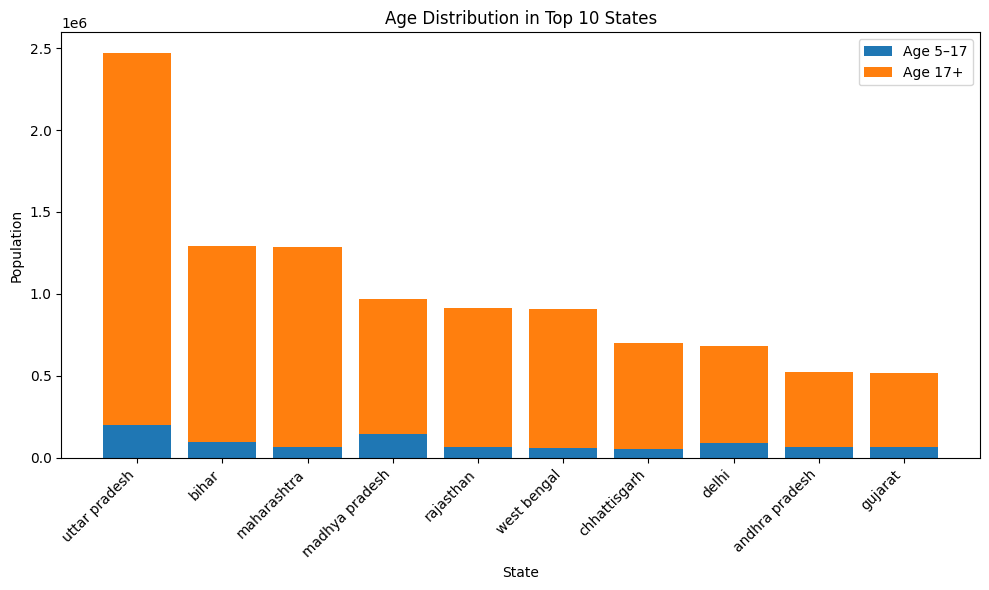

In [45]:
top10 = state_summary.sort_values('total_population', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10['state'], top10['age_5_17'], label='Age 5–17')
plt.bar(top10['state'], top10['age_17_plus'],
        bottom=top10['age_5_17'], label='Age 17+')

plt.xticks(rotation=45, ha='right')
plt.title('Age Distribution in Top 10 States')
plt.xlabel('State')
plt.ylabel('Population')
plt.legend()
plt.tight_layout()
plt.savefig("../outputs/charts/top_10_age_distribution.png", dpi=300)
plt.show()


1. The Aadhaar demographic base is adult heavy.
2. In all the 10 states, the Age 17+ section is much larger than the Age 5-17 section. This could also have been because the Aadhaar coverage is high among adults.
3. UP is the single biggest contributor to Aadhaar demographic records.
4. Bihar, UP and Madhya Pradesh have a relatively larger child share.
5. Delhi and Gujrat have smaller child proportion, meaning it has a more adult heavy profile. This can correlate with Urbanization and Migration of working age adults.
6. This means that states with more children today will need more update capacity in the future. States like Bihar,UP and MP need future planning and scaling.
7. Delhi and Gujrat would need maintenance and service quality
8. This can also show the probability of migration of people from states like Bihar and UP once people reach a certain working age.

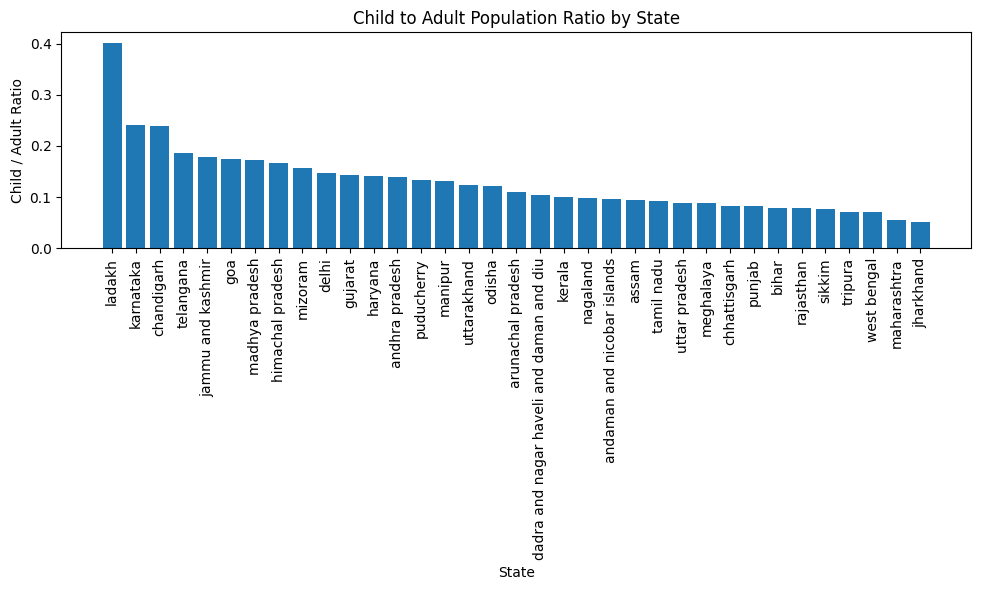

In [48]:
state_summary['child_to_adult_ratio'] = (
    state_summary['age_5_17'] / state_summary['age_17_plus']
)
ratio_sorted = state_summary.sort_values('child_to_adult_ratio', ascending=False)

plt.figure(figsize=(10,6))
plt.bar(ratio_sorted['state'], ratio_sorted['child_to_adult_ratio'])
plt.xticks(rotation=90)
plt.title('Child to Adult Population Ratio by State')
plt.xlabel('State')
plt.ylabel('Child / Adult Ratio')
plt.tight_layout()
plt.savefig("../outputs/charts/child_adult_ratio.png", dpi=300)
plt.show()

1. Ladakh has a very young demographic structure. It has a small population but high future update intensity per adult.
2. Southern states and certain union territories show higher youth ratio. Therefore, it will see higher child enrollment and biometric updates at age milestones.
3. States like Maharashtra, West Bengal, Rajasthan and Bihar have low child-to-adult ratios meaning the aadhaar update demand is for adult corrections, address change and migration. These states need to be maintainence focused.
4. Population volume alone cannot predict future Aadhaar update demand.

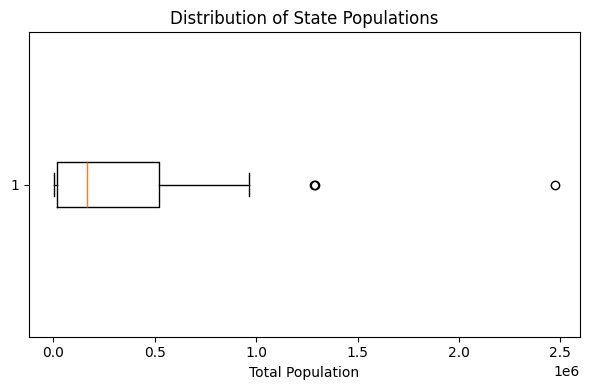

In [49]:
plt.figure(figsize=(6,4))
plt.boxplot(state_summary['total_population'], vert=False)
plt.title('Distribution of State Populations')
plt.xlabel('Total Population')
plt.tight_layout()
plt.savefig("../outputs/charts/distribution_of_state_population.png", dpi=300)
plt.show()

1. This graph shows that most of the states have relatively small population and a few states are extremely large.
2. As the median line is closer to the left side, it means that more than half of the cities are below the mean.
This means that if we plan for the arrangements considering the average, it may not suit either extremes.